Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

# ROC-AUC curve visualisation

In [16]:
results = {"auc": [], "variable": [], "model": []}

In [17]:
standard_model_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
)
standard_model_hgf_df = standard_model_hgf_df[standard_model_hgf_df.session == 2]

variables_list = [
    ["extero_threshold", "intero_threshold"],
    ["extero_slope", "intero_slope"],
]

for variables, name in zip(variables_list, ["Threshold", "Slope"]):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        standard_model_hgf_df[var_1],
        standard_model_hgf_df[var_2],
        paired=False,
        eftype="AUC",
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("Dynamic beliefs")
    results["variable"].append(name)

In [18]:
cardiac_believing_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
)
cardiac_believing_hgf_df = cardiac_believing_hgf_df[
    cardiac_believing_hgf_df.session == 2
]

variables_list = [
    ["intero_std", "extero_slope"],
]

for variables, name in zip(variables_list, ["Slope"]):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        cardiac_believing_hgf_df[var_1],
        cardiac_believing_hgf_df[var_2],
        paired=False,
        eftype="AUC",
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("Static beliefs")
    results["variable"].append(name)

In [19]:
weighted_update_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "weighted_update_summary.csv"
)
weighted_update_df = weighted_update_df[weighted_update_df.session == 2]

variables_list = [
    ["logit_exteroceptive_sensitivity", "logit_interoceptive_sensitivity"],
    ["pi_cardiac_belief", "pi_extero_belief"],
    ["mu_cardiac_prior", "mu_extero_prior"],
]

for variables, name in zip(
    variables_list, ["Sensitivity", "Belief precision", "Belief average"]
):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        weighted_update_df[var_1], weighted_update_df[var_2], paired=False, eftype="AUC"
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("Weighted update")
    results["variable"].append(name)

In [20]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
cardiac_hgf_df = cardiac_hgf_df[cardiac_hgf_df.session == 2]

variables_list = [
    ["logit_exteroceptive_sensitivity", "logit_interoceptive_sensitivity"],
    ["interoceptive_mean", "exteroceptive_mean"],
    ["interoceptive_precision", "exteroceptive_precision"],
]

for variables, name in zip(
    variables_list, ["Sensitivity", "Belief average", "Belief precision"]
):
    var_1, var_2 = variables
    auc = pg.compute_effsize(
        cardiac_hgf_df[var_1], cardiac_hgf_df[var_2], paired=False, eftype="AUC"
    )
    auc = auc if auc > 0.5 else 1.0 - auc
    results["auc"].append(auc)
    results["model"].append("Cardiac HGF")
    results["variable"].append(name)

In [21]:
aucs = np.asarray(results["auc"])
variables = np.asarray(results["variable"])
models = np.asarray(results["model"])

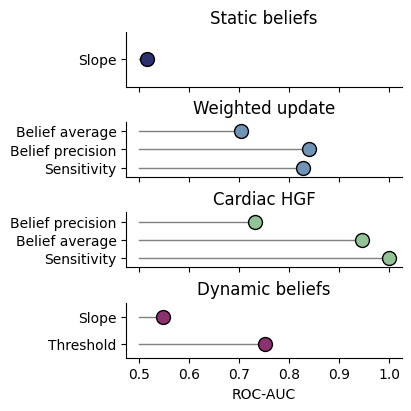

In [22]:
_, axs = plt.subplots(figsize=(4, 4), nrows=4, sharex=True)

# Use a set to track unique labels and avoid duplicates
for i, model, color in zip(
    range(4),
    ["Static beliefs", "Weighted update", "Cardiac HGF", "Dynamic beliefs"],
    ["#2c3071", "#6f94b5", "#92c396", "#8b3170"],
):
    for ii, (auc, var) in enumerate(
        zip(aucs[models == model], variables[models == model])
    ):
        axs[i].plot([0.5, auc], [ii, ii], color="grey", linewidth=1.0)
        axs[i].scatter(y=ii, x=auc, color=color, edgecolor="k", s=100, zorder=2)
    axs[i].set(title=model, ylim=(-0.5, ii + 0.5))
    axs[i].set_yticks(
        [i for i in range(ii + 1)], [str(var) for var in variables[models == model]]
    )

axs[3].set(xlabel="ROC-AUC")
sns.despine()

plt.savefig(
    Path().cwd().parent.parent / "figures" / "figure_5_ROC_AUC.svg", bbox_inches="tight"
)

In [10]:
pd.DataFrame(results)

,auc,variable,model
0,0.752172,Threshold,Dynamic beliefs
1,0.549489,Slope,Dynamic beliefs
2,1.000000,Threshold,Static beliefs
3,0.517470,Slope,Static beliefs
4,0.827537,Sensitivity,Weighted update
5,0.839661,Belief precision,Weighted update
6,0.704834,Belief average,Weighted update
7,0.999982,Sensitivity,Cardiac HGF
8,0.945735,Belief average,Cardiac HGF
9,0.731727,Belief precision,Cardiac HGF
